In [24]:
# =========================
# IMPORTAR LIBRERÍAS
# =========================
# pandas y numpy para trabajar con datos
# matplotlib y seaborn para gráficos

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Mostrar más columnas y filas en pantalla
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

# Tamaño general de los gráficos y estilo visual
plt.rcParams["figure.figsize"] = (10, 6)
sns.set_theme(style="whitegrid")

In [25]:
# =========================
# CARGAR EL DATASET FINAL LIMPIO
# =========================
# Leemos el CSV final que ya preparaste en el notebook 02

df = pd.read_csv("../data/processed/dataset_final_aire_meteo_zaragoza_limpio.csv")

# Convertimos fecha y datetime a formato fecha real
df["fecha"] = pd.to_datetime(df["fecha"], errors="coerce")
df["datetime"] = pd.to_datetime(df["datetime"], errors="coerce", format="mixed")

# Creamos columnas temporales útiles para el análisis
df["anio"] = df["datetime"].dt.year
df["mes_num"] = df["datetime"].dt.month
df["hora_real"] = df["datetime"].dt.hour

# Asignamos una unidad abreviada a cada contaminante
# CO suele expresarse en mg/m3
# El resto, normalmente en µg/m3
unidad_map = {
    "CO": "mg/m3",
    "NO": "µg/m3",
    "NO2": "µg/m3",
    "O3": "µg/m3",
    "PM10": "µg/m3",
    "PM2.5": "µg/m3",
    "SO2": "µg/m3"
}

df["unidad"] = df["contaminante"].map(unidad_map)

# Creamos una etiqueta más visual para las estaciones
df["estacion_label"] = "Estación " + df["estacion"].astype(str)

# Nos quedamos con las filas que sí tienen medida de contaminación
df_valid = df.dropna(subset=["valor"]).copy()

print("Shape total:", df.shape)
print("Shape sin nulos en valor:", df_valid.shape)
display(df_valid.head())

C:\Users\kevin\AppData\Local\Temp\ipykernel_6976\2165081732.py:6: DtypeWarning: Columns (0: datetime, 1: estacion_meteo, 2: provincia_meteo, 3: prec_traza) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("../data/processed/dataset_final_aire_meteo_zaragoza_limpio.csv")


Shape total: (1304856, 45)
Shape sin nulos en valor: (1260016, 45)


,provincia,municipio,estacion,magnitud,contaminante,punto_muestreo,archivo_origen,anno,mes,dia,hora,valor,fecha,datetime,anio,mes_num,mes_nombre,dia_mes,dia_semana_num,dia_semana,fin_de_semana,estacion_anio,franja_horaria,idema,estacion_meteo,provincia_meteo,altitud_meteo,temp_media,precipitacion,prec_traza,temp_min,temp_max,viento_vel_media,direccion_viento,racha_max,insolacion,presion_max,presion_min,anio_meteo,mes_meteo,dia_meteo,hora_real,trimestre,unidad,estacion_label
0,50,297,26,6,CO,50297026_6_48,aire_2020.csv,2020,1,1,1,0.20,2020-01-01,2020-01-01,2020.0,1.0,Enero,1.0,2,Miércoles,False,Invierno,Madrugada,9434.0,"ZARAGOZA, AEROPUERTO",ZARAGOZA,249.0,1.0,0.0,False,0.3,1.8,1.7,28.0,5.6,0.0,1004.6,1001.9,2020.0,1.0,1.0,0.0,1.0,mg/m3,Estación 26
1,50,297,26,8,NO2,50297026_8_8,aire_2020.csv,2020,1,1,1,13.39,2020-01-01,2020-01-01,2020.0,1.0,Enero,1.0,2,Miércoles,False,Invierno,Madrugada,9434.0,"ZARAGOZA, AEROPUERTO",ZARAGOZA,249.0,1.0,0.0,False,0.3,1.8,1.7,28.0,5.6,0.0,1004.6,1001.9,2020.0,1.0,1.0,0.0,1.0,µg/m3,Estación 26
2,50,297,26,14,O3,50297026_14_6,aire_2020.csv,2020,1,1,1,16.88,2020-01-01,2020-01-01,2020.0,1.0,Enero,1.0,2,Miércoles,False,Invierno,Madrugada,9434.0,"ZARAGOZA, AEROPUERTO",ZARAGOZA,249.0,1.0,0.0,False,0.3,1.8,1.7,28.0,5.6,0.0,1004.6,1001.9,2020.0,1.0,1.0,0.0,1.0,µg/m3,Estación 26
3,50,297,29,6,CO,50297029_6_48,aire_2020.csv,2020,1,1,1,0.21,2020-01-01,2020-01-01,2020.0,1.0,Enero,1.0,2,Miércoles,False,Invierno,Madrugada,9434.0,"ZARAGOZA, AEROPUERTO",ZARAGOZA,249.0,1.0,0.0,False,0.3,1.8,1.7,28.0,5.6,0.0,1004.6,1001.9,2020.0,1.0,1.0,0.0,1.0,mg/m3,Estación 29
4,50,297,29,8,NO2,50297029_8_8,aire_2020.csv,2020,1,1,1,19.90,2020-01-01,2020-01-01,2020.0,1.0,Enero,1.0,2,Miércoles,False,Invierno,Madrugada,9434.0,"ZARAGOZA, AEROPUERTO",ZARAGOZA,249.0,1.0,0.0,False,0.3,1.8,1.7,28.0,5.6,0.0,1004.6,1001.9,2020.0,1.0,1.0,0.0,1.0,µg/m3,Estación 29


In [26]:
# =========================
# REVISIÓN GENERAL DEL DATASET
# =========================
# Aquí comprobamos lo más importante:
# - columnas
# - contaminantes
# - estaciones
# - rango temporal

print("Columnas:")
print(df_valid.columns.tolist())

print("\nContaminantes:")
print(sorted(df_valid["contaminante"].dropna().unique().tolist()))

print("\nUnidades por contaminante:")
display(
    df_valid[["contaminante", "unidad"]]
    .drop_duplicates()
    .sort_values("contaminante")
)

print("\nEstaciones:")
print(sorted(df_valid["estacion"].dropna().unique().tolist()))

print("\nRango temporal:")
print(df_valid["datetime"].min(), "->", df_valid["datetime"].max())

Columnas:
['provincia', 'municipio', 'estacion', 'magnitud', 'contaminante', 'punto_muestreo', 'archivo_origen', 'anno', 'mes', 'dia', 'hora', 'valor', 'fecha', 'datetime', 'anio', 'mes_num', 'mes_nombre', 'dia_mes', 'dia_semana_num', 'dia_semana', 'fin_de_semana', 'estacion_anio', 'franja_horaria', 'idema', 'estacion_meteo', 'provincia_meteo', 'altitud_meteo', 'temp_media', 'precipitacion', 'prec_traza', 'temp_min', 'temp_max', 'viento_vel_media', 'direccion_viento', 'racha_max', 'insolacion', 'presion_max', 'presion_min', 'anio_meteo', 'mes_meteo', 'dia_meteo', 'hora_real', 'trimestre', 'unidad', 'estacion_label']

Contaminantes:
['CO', 'NO', 'NO2', 'O3', 'PM10', 'PM2.5', 'SO2']

Unidades por contaminante:


,contaminante,unidad
0,CO,mg/m3
923809,NO,µg/m3
1,NO2,µg/m3
2,O3,µg/m3
6,PM10,µg/m3
498761,PM2.5,µg/m3
7,SO2,µg/m3



Estaciones:
[26, 29, 32, 36, 37, 38, 39, 40]

Rango temporal:
2020-01-01 00:00:00 -> 2023-11-30 00:00:00


In [27]:
# =========================
# RESUMEN ESTADÍSTICO POR CONTAMINANTE
# =========================
# Calculamos:
# - número de registros
# - media
# - mediana
# - desviación estándar
# - mínimo
# - máximo

resumen_contaminante = (
    df_valid.groupby(["contaminante", "unidad"])
    .agg(
        registros=("valor", "size"),
        media=("valor", "mean"),
        mediana=("valor", "median"),
        desviacion_std=("valor", "std"),
        minimo=("valor", "min"),
        maximo=("valor", "max")
    )
    .reset_index()
    .sort_values(["unidad", "contaminante"])
)

display(resumen_contaminante)

,contaminante,unidad,registros,media,mediana,desviacion_std,minimo,maximo
0,CO,mg/m3,237706,0.198016,0.18,0.087498,0.02,2.19
1,NO,µg/m3,66351,7.760430,4.68,11.307598,0.00,327.71
2,NO2,µg/m3,270369,20.023261,15.86,14.021811,1.00,177.73
3,O3,µg/m3,273226,50.935175,53.47,27.758891,0.10,173.12
4,PM10,µg/m3,186286,18.194829,15.15,13.634353,0.00,168.30
5,PM2.5,µg/m3,19615,8.571669,7.45,6.192152,0.10,93.69
6,SO2,µg/m3,206463,4.306574,3.99,1.898421,0.03,42.48


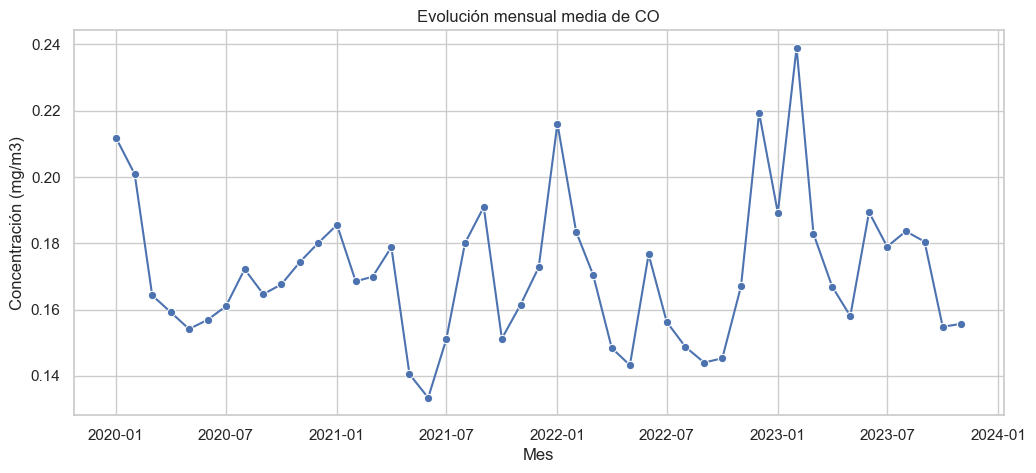

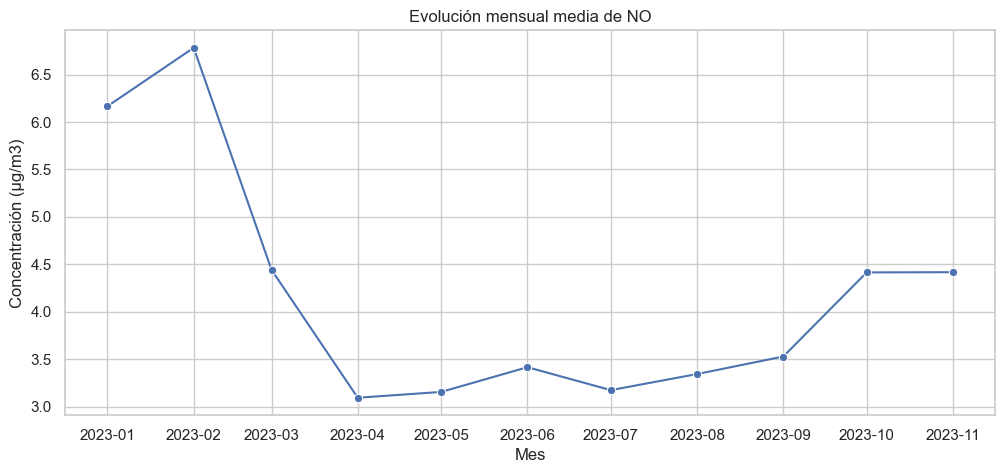

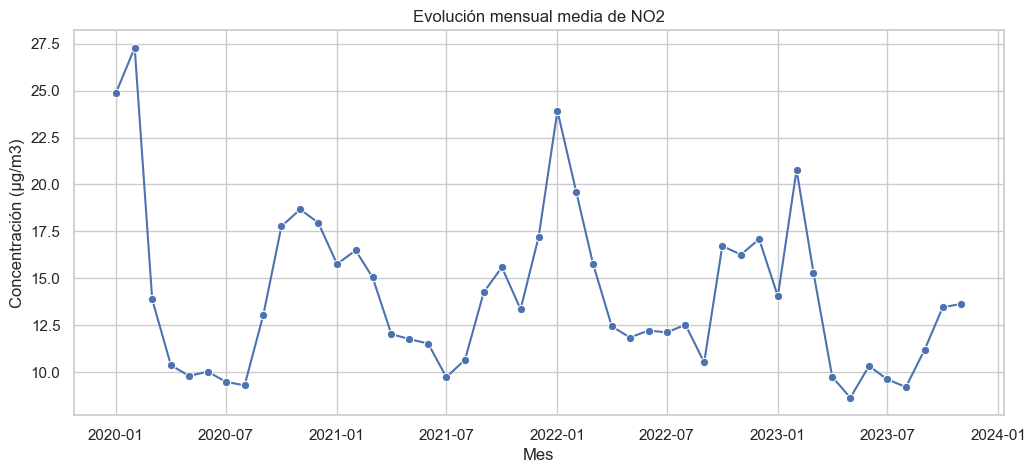

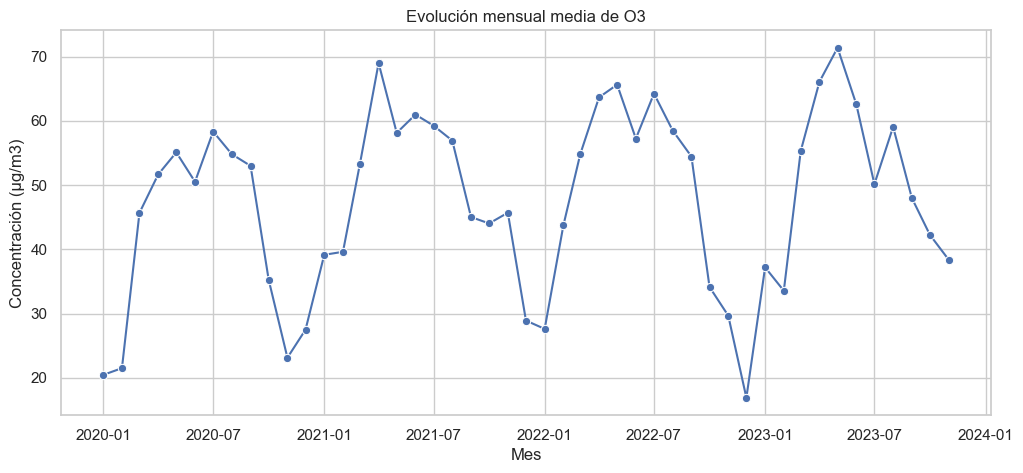

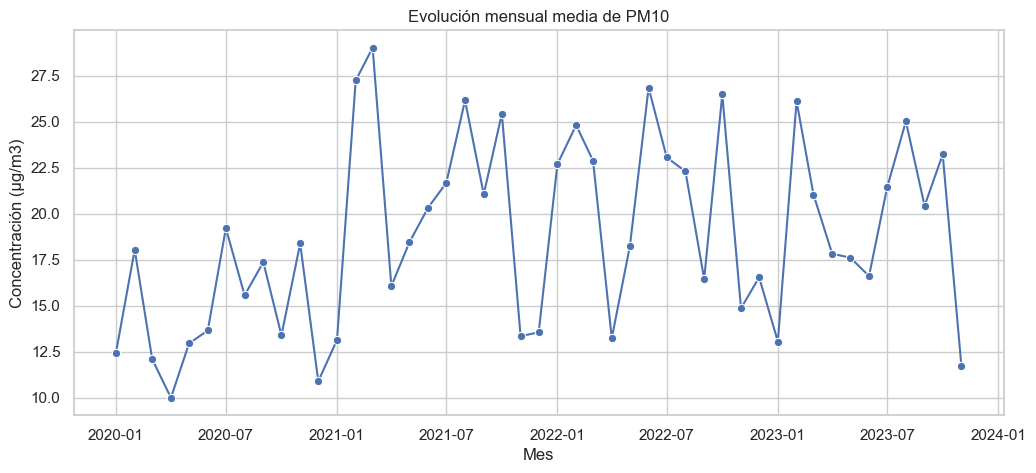

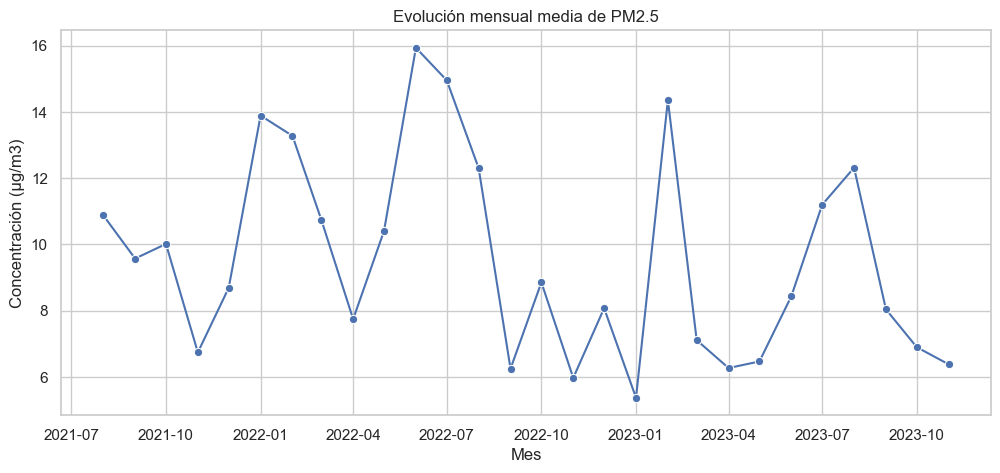

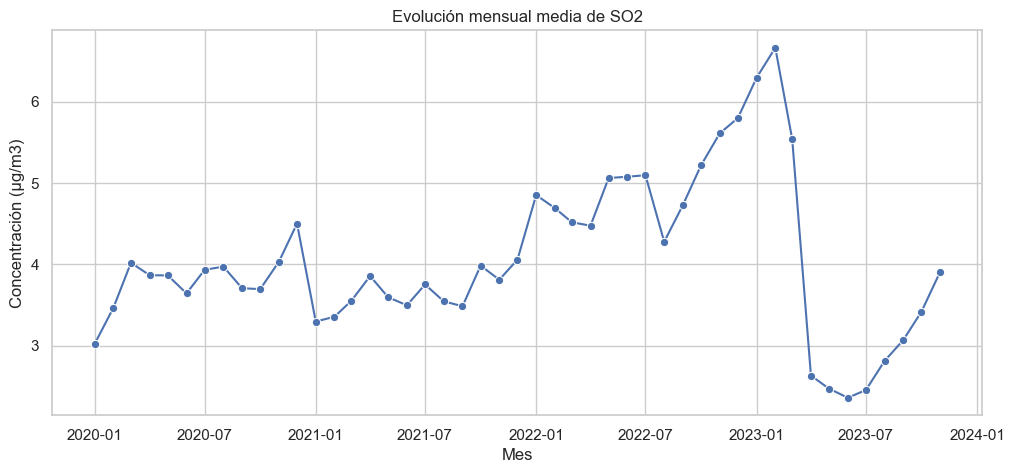

In [28]:
# =========================
# EVOLUCIÓN MENSUAL POR CONTAMINANTE
# =========================
# En vez de mezclar todos los contaminantes en una sola gráfica,
# hacemos una gráfica por contaminante.
# Así evitamos mezclar unidades y queda mucho más limpio.

contaminantes = sorted(df_valid["contaminante"].dropna().unique().tolist())

for contaminante in contaminantes:
    # Filtramos solo un contaminante
    df_plot = df_valid[df_valid["contaminante"] == contaminante].copy()

    # Calculamos la media mensual
    evolucion = (
        df_plot.groupby(["anio", "mes_num"])["valor"]
        .mean()
        .reset_index()
    )

    # Aseguramos enteros para construir bien la fecha
    evolucion["anio"] = evolucion["anio"].astype(int)
    evolucion["mes_num"] = evolucion["mes_num"].astype(int)

    # Creamos una fecha con el primer día de cada mes
    evolucion["fecha_mes"] = pd.to_datetime(
        dict(
            year=evolucion["anio"],
            month=evolucion["mes_num"],
            day=1
        )
    )

    # Sacamos la unidad de ese contaminante
    unidad = df_plot["unidad"].dropna().iloc[0]

    # Dibujamos la gráfica
    plt.figure(figsize=(12, 5))
    sns.lineplot(data=evolucion, x="fecha_mes", y="valor", marker="o")
    plt.title(f"Evolución mensual media de {contaminante}")
    plt.xlabel("Mes")
    plt.ylabel(f"Concentración ({unidad})")
    plt.show()

In [ ]:
# =========================
# TABLA RESUMEN POR ESTACIÓN Y CONTAMINANTE
# =========================
# Esta tabla permite ver qué estación registra
# mayores concentraciones medias para cada contaminante.

tabla_estacion_contaminante = (
    df_valid.groupby(["estacion_label", "contaminante", "unidad"])
    .agg(
        registros=("valor", "size"),
        media=("valor", "mean"),
        mediana=("valor", "median"),
        minimo=("valor", "min"),
        maximo=("valor", "max")
    )
    .reset_index()
    .sort_values(["contaminante", "media"], ascending=[True, False])
)

display(tabla_estacion_contaminante.head(30))

,estacion_label,contaminante,unidad,registros,media,mediana,minimo,maximo
5,Estación 29,CO,mg/m3,34451,0.238716,0.21,0.07,1.76
29,Estación 38,CO,mg/m3,33780,0.217703,0.20,0.10,1.76
34,Estación 39,CO,mg/m3,34066,0.200860,0.19,0.10,1.89
17,Estación 36,CO,mg/m3,34272,0.194483,0.18,0.05,2.19
0,Estación 26,CO,mg/m3,33770,0.189966,0.17,0.02,1.15
23,Estación 37,CO,mg/m3,34152,0.184479,0.17,0.10,1.09
11,Estación 32,CO,mg/m3,33215,0.158610,0.15,0.03,0.97
6,Estación 29,NO,µg/m3,8364,10.551649,7.61,0.21,174.72
35,Estación 39,NO,µg/m3,8070,8.961116,4.73,1.00,186.42
30,Estación 38,NO,µg/m3,7845,8.544436,4.89,1.00,327.71


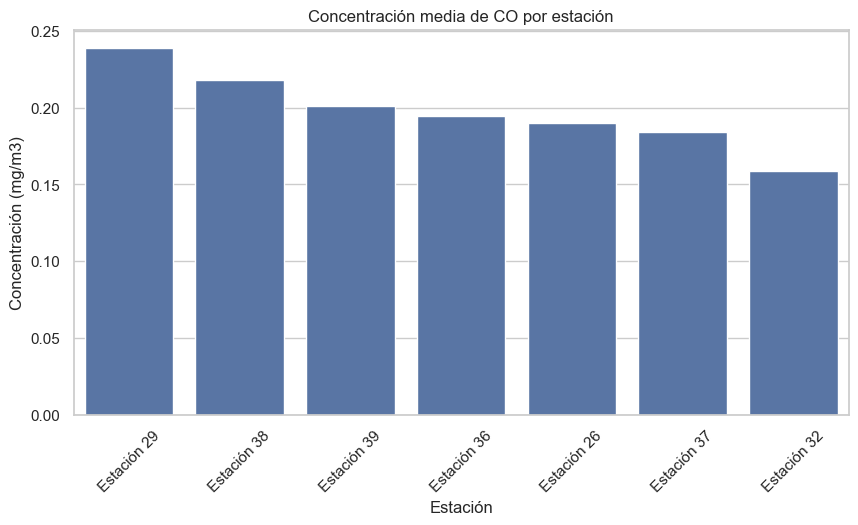

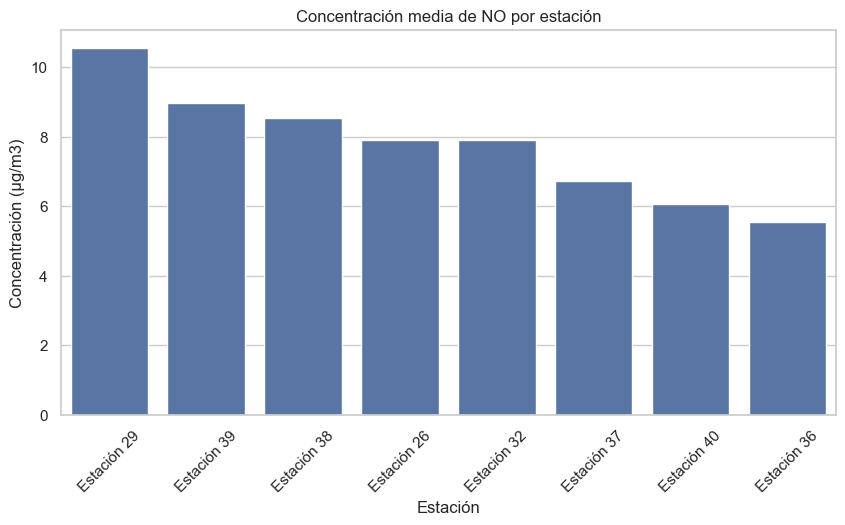

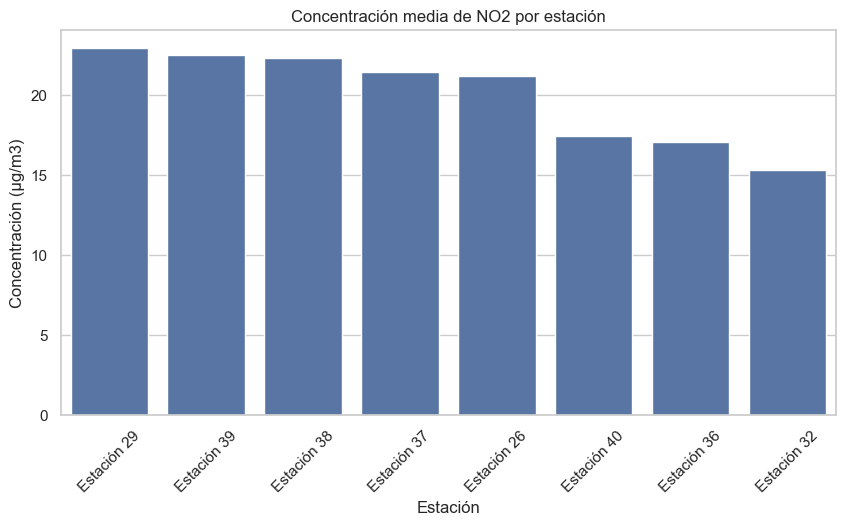

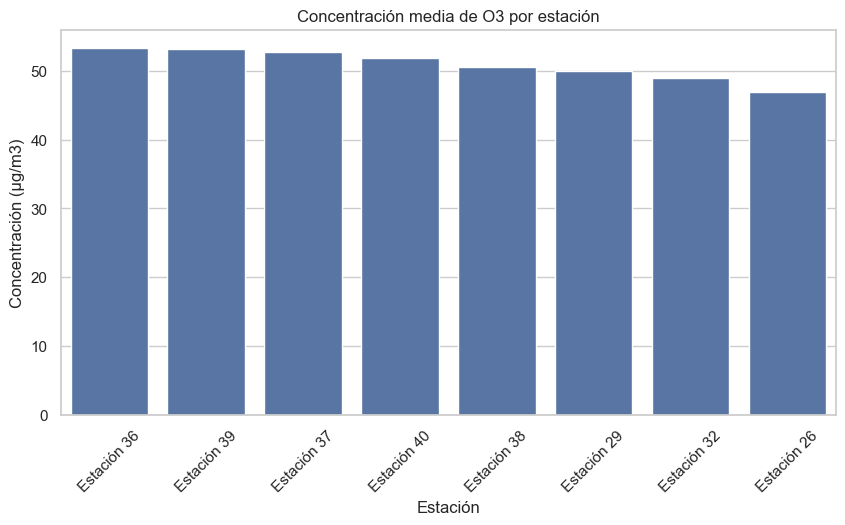

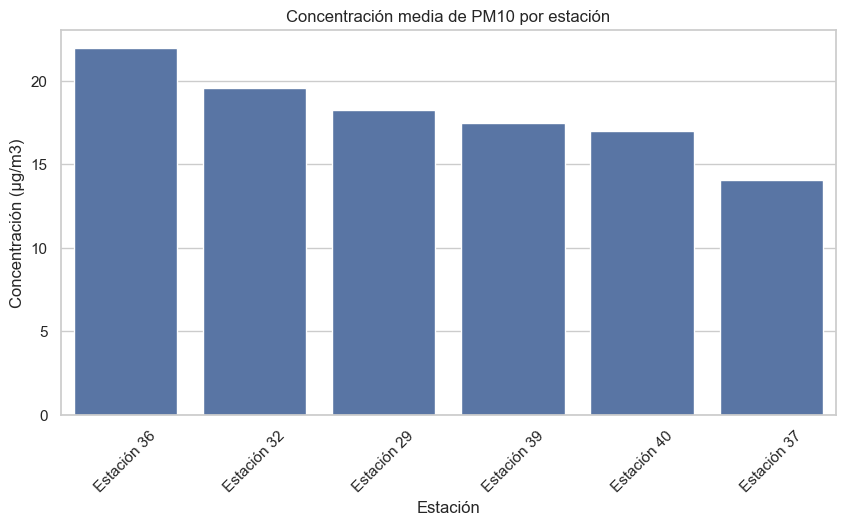

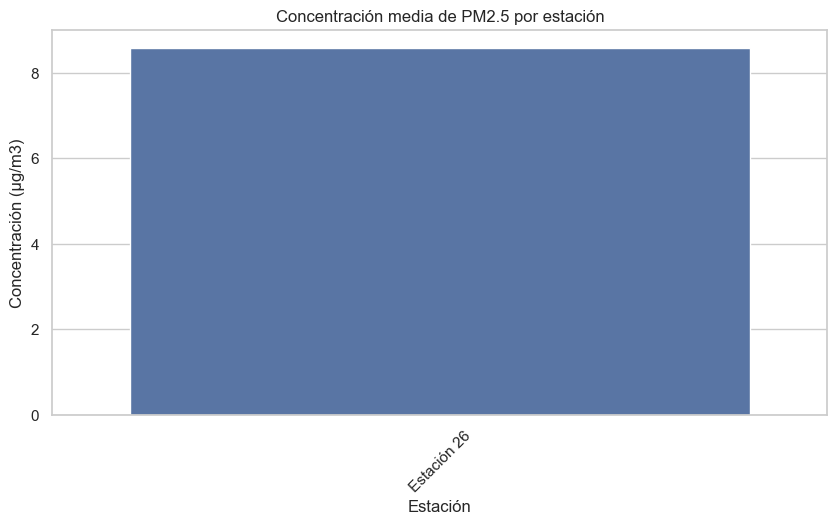

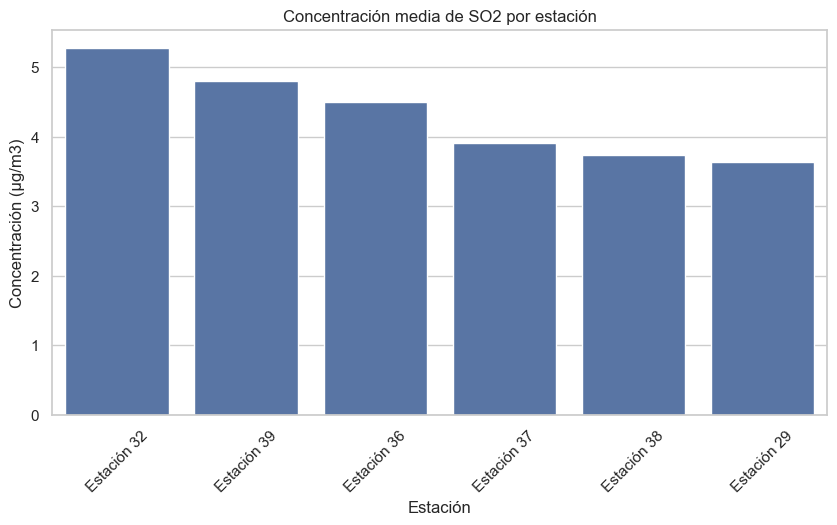

In [30]:
# =========================
# MEDIA POR ESTACIÓN PARA CADA CONTAMINANTE
# =========================
# Queremos ver en qué estaciones se registran
# concentraciones medias más altas para cada contaminante.

contaminantes = sorted(df_valid["contaminante"].dropna().unique().tolist())

for contaminante in contaminantes:
    # Filtramos el contaminante
    df_plot = (
        df_valid[df_valid["contaminante"] == contaminante]
        .groupby("estacion_label")["valor"]
        .mean()
        .sort_values(ascending=False)
        .reset_index()
    )

    # Obtenemos la unidad
    unidad = df_valid.loc[df_valid["contaminante"] == contaminante, "unidad"].dropna().iloc[0]

    # Dibujamos barras
    plt.figure(figsize=(10, 5))
    sns.barplot(data=df_plot, x="estacion_label", y="valor")
    plt.title(f"Concentración media de {contaminante} por estación")
    plt.xlabel("Estación")
    plt.ylabel(f"Concentración ({unidad})")
    plt.xticks(rotation=45)
    plt.show()

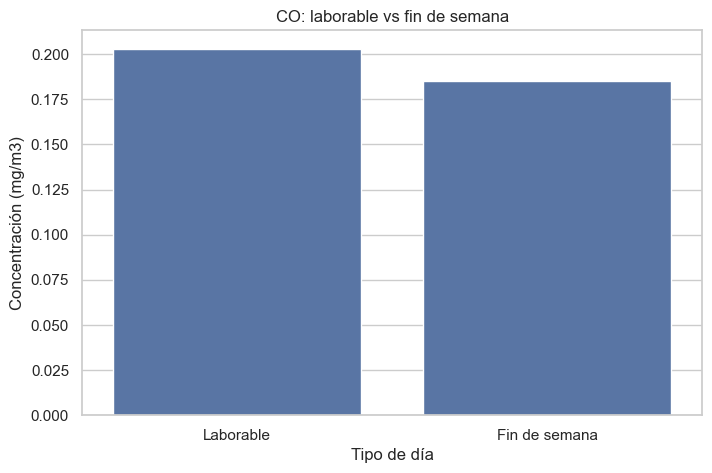

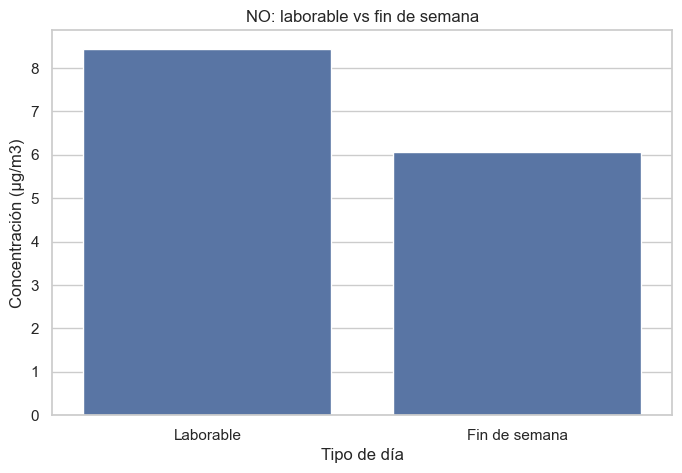

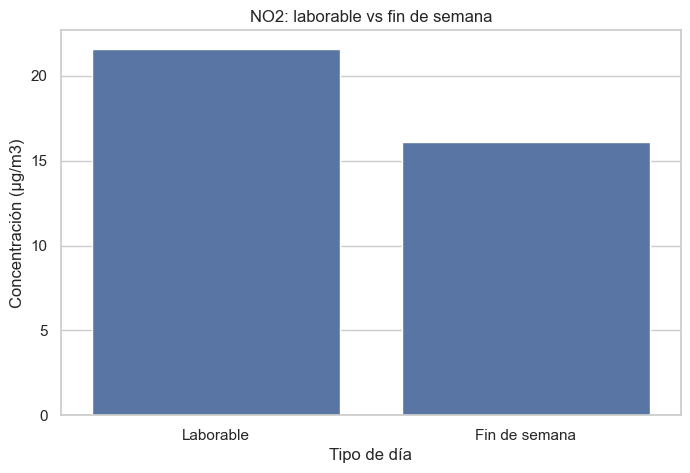

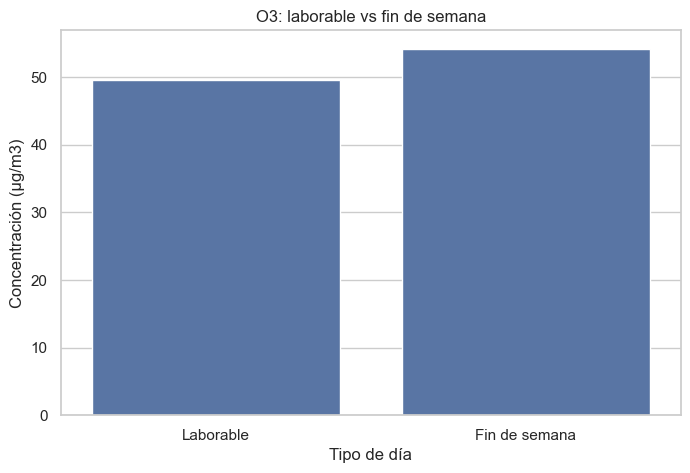

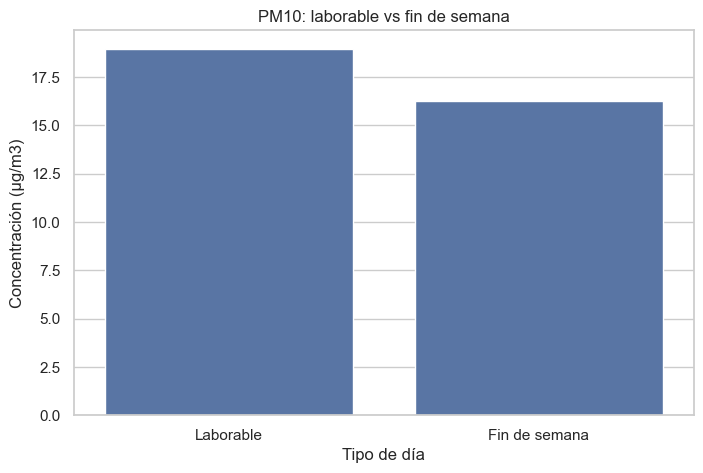

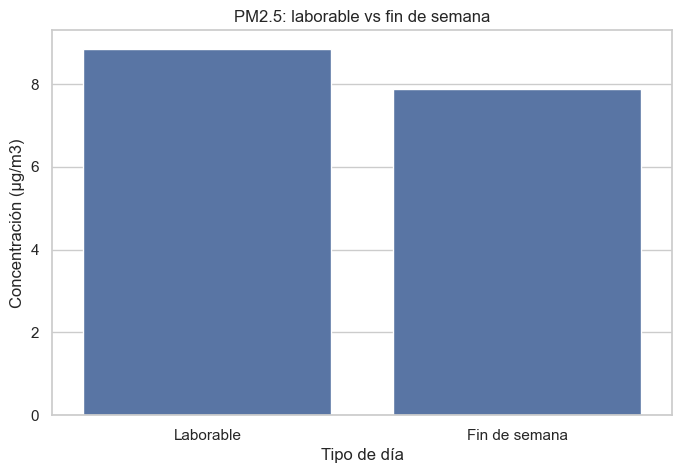

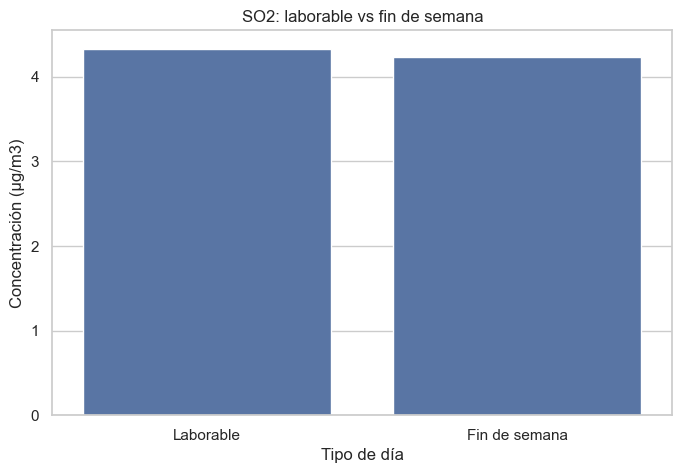

In [31]:
# =========================
# COMPARATIVA LABORABLE VS FIN DE SEMANA
# =========================
# Comparamos si la contaminación cambia entre
# días laborables y fines de semana.

comparativa_tipo_dia = (
    df_valid.groupby(["contaminante", "unidad", "fin_de_semana"])["valor"]
    .mean()
    .reset_index()
)

# Convertimos True/False a etiquetas más legibles
comparativa_tipo_dia["tipo_dia"] = comparativa_tipo_dia["fin_de_semana"].map({
    False: "Laborable",
    True: "Fin de semana"
})

contaminantes = sorted(df_valid["contaminante"].dropna().unique().tolist())

for contaminante in contaminantes:
    # Filtramos el contaminante
    df_plot = comparativa_tipo_dia[comparativa_tipo_dia["contaminante"] == contaminante].copy()

    # Unidad
    unidad = df_plot["unidad"].dropna().iloc[0]

    # Gráfico
    plt.figure(figsize=(8, 5))
    sns.barplot(data=df_plot, x="tipo_dia", y="valor")
    plt.title(f"{contaminante}: laborable vs fin de semana")
    plt.xlabel("Tipo de día")
    plt.ylabel(f"Concentración ({unidad})")
    plt.show()

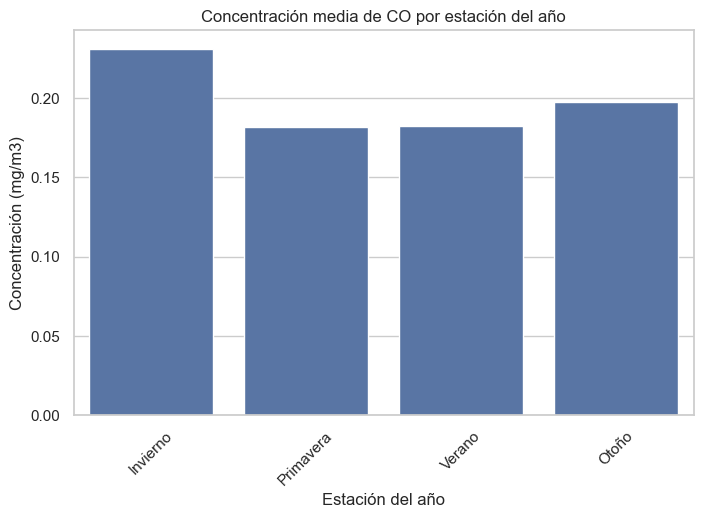

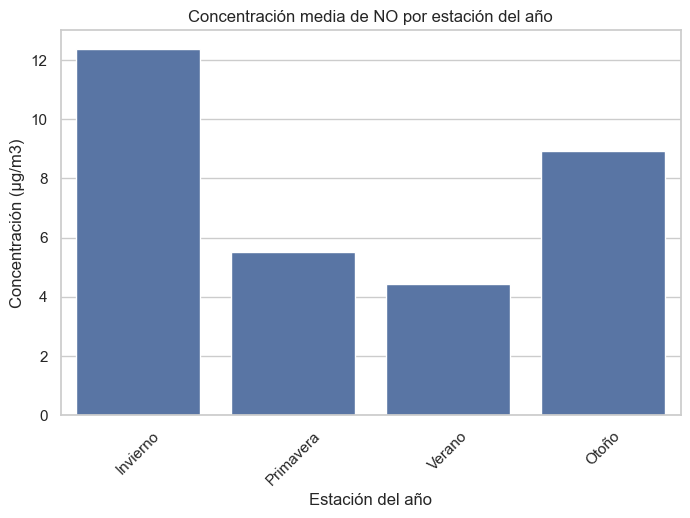

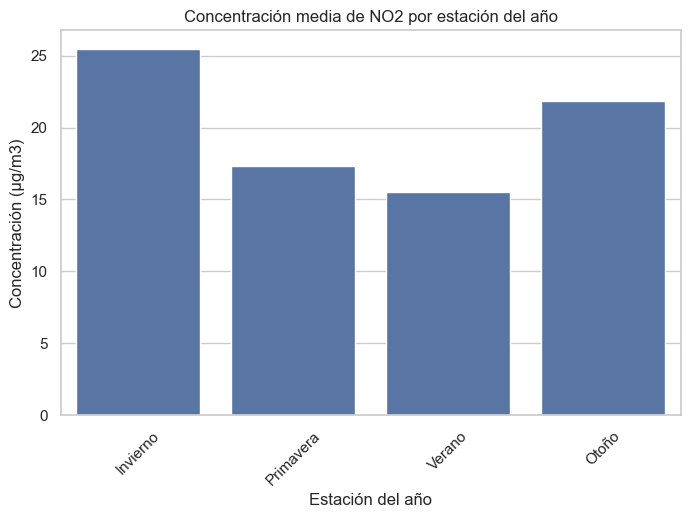

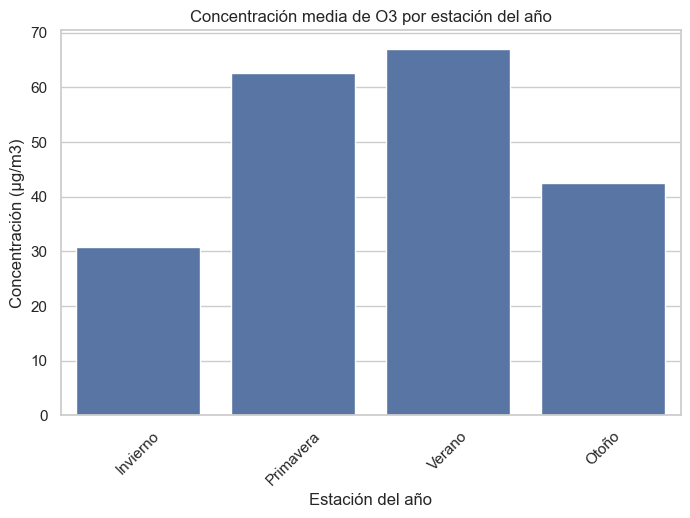

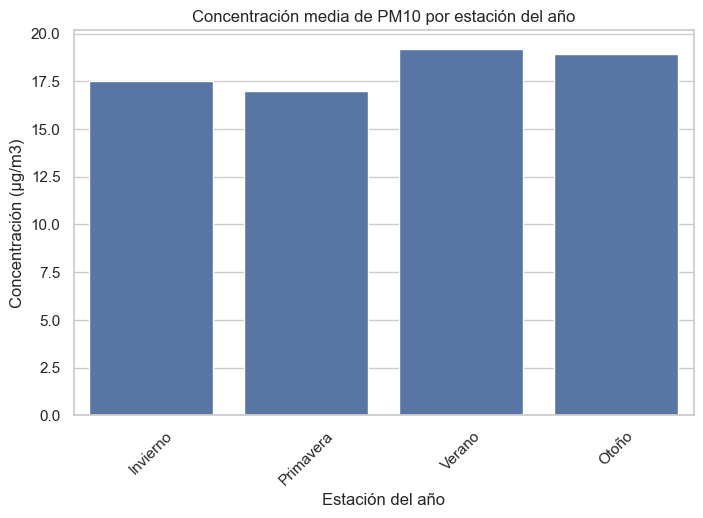

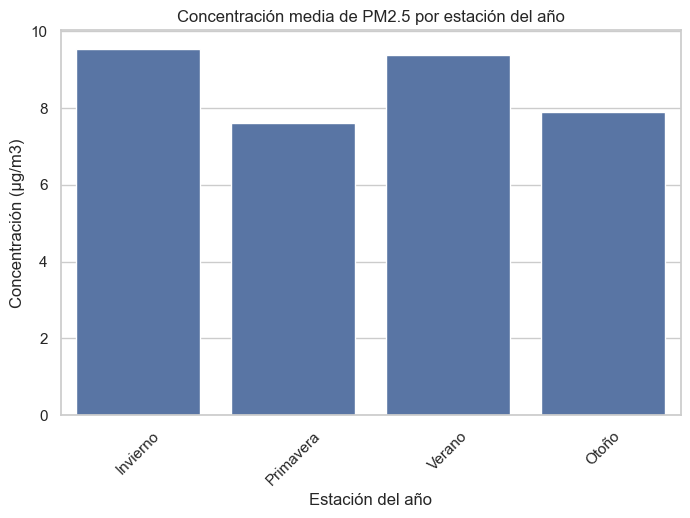

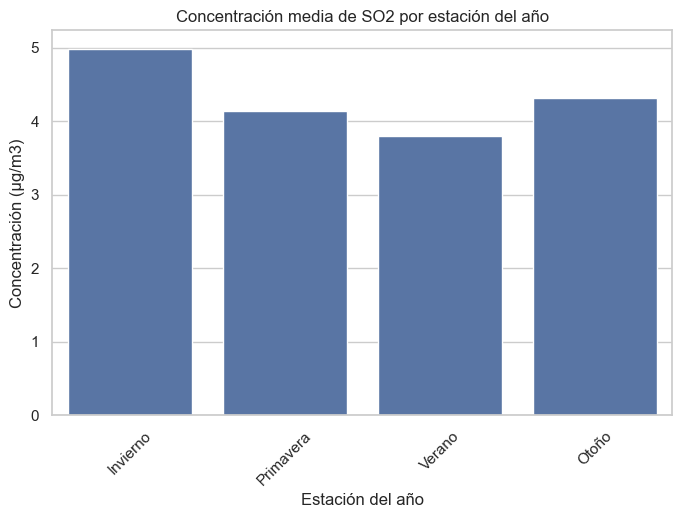

In [37]:
# =========================
# MEDIA POR ESTACIÓN DEL AÑO Y CONTAMINANTE
# =========================
# Analizamos si las concentraciones cambian
# según invierno, primavera, verano u otoño.

media_estacion_anio = (
    df_valid.groupby(["contaminante", "unidad", "estacion_anio"])["valor"]
    .mean()
    .reset_index()
)

orden_estaciones = ["Invierno", "Primavera", "Verano", "Otoño"]

contaminantes = sorted(df_valid["contaminante"].dropna().unique().tolist())

for contaminante in contaminantes:
    # Filtramos el contaminante
    df_plot = media_estacion_anio[media_estacion_anio["contaminante"] == contaminante].copy()

    # Ordenamos la estación del año
    df_plot["estacion_anio"] = pd.Categorical(
        df_plot["estacion_anio"],
        categories=orden_estaciones,
        ordered=True
    )
    df_plot = df_plot.sort_values("estacion_anio")

    # Unidad
    unidad = df_plot["unidad"].dropna().iloc[0]

    # Gráfico
    plt.figure(figsize=(8, 5))
    sns.barplot(data=df_plot, x="estacion_anio", y="valor")
    plt.title(f"Concentración media de {contaminante} por estación del año")
    plt.xlabel("Estación del año")
    plt.ylabel(f"Concentración ({unidad})")
    plt.xticks(rotation=45)
    plt.show()

,contaminante,unidad,correlacion_temp,etiqueta
3,O3,µg/m3,0.448462,O3 (µg/m3)
4,PM10,µg/m3,0.095766,PM10 (µg/m3)
5,PM2.5,µg/m3,0.052845,PM2.5 (µg/m3)
6,SO2,µg/m3,-0.153893,SO2 (µg/m3)
0,CO,mg/m3,-0.187620,CO (mg/m3)
2,NO2,µg/m3,-0.197319,NO2 (µg/m3)
1,NO,µg/m3,-0.263926,NO (µg/m3)


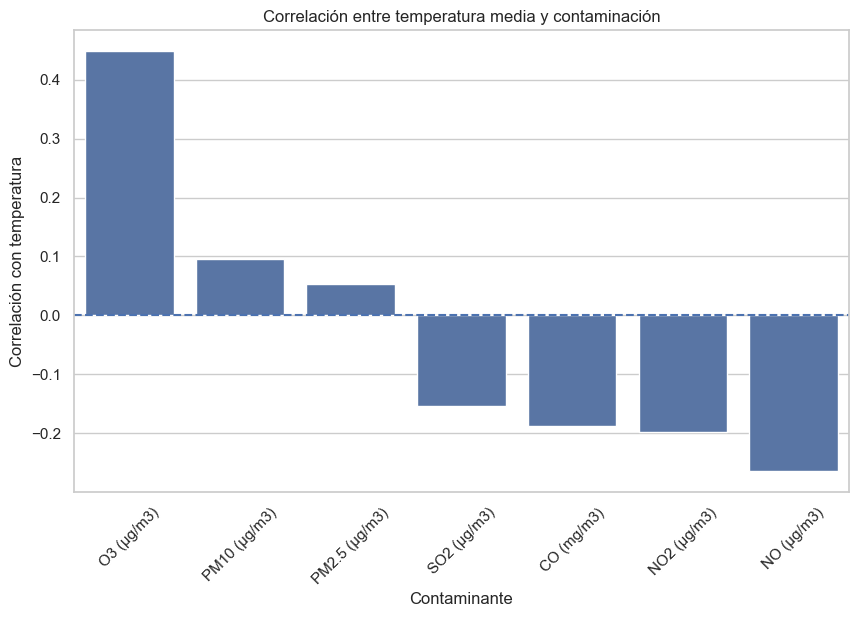

In [40]:
# =========================
# CORRELACIÓN ENTRE TEMPERATURA Y CONTAMINACIÓN
# POR CONTAMINANTE
# =========================
# Calculamos la correlación entre la temperatura media
# y la concentración de cada contaminante.

corr_temp = (
    df_valid.groupby(["contaminante", "unidad"])
    .apply(lambda x: x["valor"].corr(x["temp_media"]))
    .reset_index(name="correlacion_temp")
    .sort_values("correlacion_temp", ascending=False)
)

corr_temp["etiqueta"] = corr_temp["contaminante"] + " (" + corr_temp["unidad"] + ")"

display(corr_temp)

plt.figure(figsize=(10, 6))
sns.barplot(data=corr_temp, x="etiqueta", y="correlacion_temp")
plt.title("Correlación entre temperatura media y contaminación")
plt.xlabel("Contaminante")
plt.ylabel("Correlación con temperatura")
plt.xticks(rotation=45)
plt.axhline(0, linestyle="--")
plt.show()

In [45]:
# =========================
# TABLA DE CORRELACIONES METEOROLÓGICAS POR CONTAMINANTE
# =========================

def calcular_correlaciones(grupo):
    return pd.Series({
        "corr_temp_media": grupo["valor"].corr(grupo["temp_media"]),
        "corr_precipitacion": grupo["valor"].corr(grupo["precipitacion"]),
        "corr_viento": grupo["valor"].corr(grupo["viento_vel_media"]),
        "corr_presion_max": grupo["valor"].corr(grupo["presion_max"]),
        "corr_presion_min": grupo["valor"].corr(grupo["presion_min"])
    })

tabla_correlaciones = (
    df_valid
    .dropna(subset=["valor"])
    .groupby(["contaminante", "unidad"], as_index=False)
    .apply(calcular_correlaciones)
    .reset_index(drop=True)
)

display(tabla_correlaciones)
print(tabla_correlaciones.columns.tolist())

,contaminante,unidad,corr_temp_media,corr_precipitacion,corr_viento,corr_presion_max,corr_presion_min
0,CO,mg/m3,-0.187620,0.044124,-0.273089,0.142309,0.140852
1,NO,µg/m3,-0.263926,-0.044956,-0.237177,0.283865,0.269706
2,NO2,µg/m3,-0.197319,0.012571,-0.318566,0.187525,0.176268
3,O3,µg/m3,0.448462,-0.055160,0.300905,-0.234565,-0.219388
4,PM10,µg/m3,0.095766,-0.035822,-0.255135,0.119894,0.126421
5,PM2.5,µg/m3,0.052845,-0.003186,-0.360518,0.194382,0.198149
6,SO2,µg/m3,-0.153893,-0.065508,-0.140084,0.135241,0.113609


['contaminante', 'unidad', 'corr_temp_media', 'corr_precipitacion', 'corr_viento', 'corr_presion_max', 'corr_presion_min']


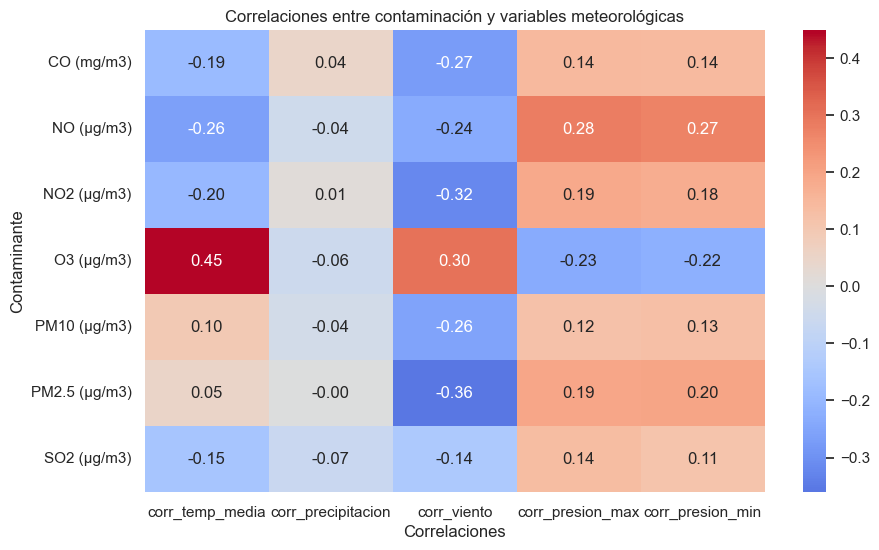

In [47]:
# =========================
# HEATMAP DE CORRELACIONES POR CONTAMINANTE
# =========================

tabla_corr_heatmap = tabla_correlaciones.copy()

tabla_corr_heatmap["etiqueta"] = (
    tabla_corr_heatmap["contaminante"].astype(str) + " (" + tabla_corr_heatmap["unidad"].astype(str) + ")"
)

tabla_corr_heatmap = tabla_corr_heatmap[
    [
        "etiqueta",
        "corr_temp_media",
        "corr_precipitacion",
        "corr_viento",
        "corr_presion_max",
        "corr_presion_min"
    ]
].set_index("etiqueta")

plt.figure(figsize=(10, 6))
sns.heatmap(tabla_corr_heatmap, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlaciones entre contaminación y variables meteorológicas")
plt.xlabel("Correlaciones")
plt.ylabel("Contaminante")
plt.show()

In [48]:
# =========================
# TABLA RESUMEN FINAL PARA CONCLUSIONES
# =========================
# Esta tabla te servirá muy bien para el informe y el README.

tabla_resumen_final = (
    df_valid.groupby(["contaminante", "unidad", "estacion_anio"])
    .agg(
        media=("valor", "mean"),
        mediana=("valor", "median"),
        maximo=("valor", "max"),
        registros=("valor", "size")
    )
    .reset_index()
    .sort_values(["contaminante", "estacion_anio"])
)

display(tabla_resumen_final.head(30))

,contaminante,unidad,estacion_anio,media,mediana,maximo,registros
0,CO,mg/m3,Invierno,0.231098,0.21,1.89,58924
1,CO,mg/m3,Otoño,0.197684,0.18,1.35,59169
2,CO,mg/m3,Primavera,0.181419,0.17,2.19,59678
3,CO,mg/m3,Verano,0.182344,0.17,0.92,59935
4,NO,µg/m3,Invierno,12.382936,7.34,248.79,16007
5,NO,µg/m3,Otoño,8.929112,5.20,327.71,16764
6,NO,µg/m3,Primavera,5.520186,4.04,129.27,16632
7,NO,µg/m3,Verano,4.437058,3.51,122.42,16948
8,NO2,µg/m3,Invierno,25.492950,21.73,177.73,66753
9,NO2,µg/m3,Otoño,21.878877,17.69,165.68,67519


In [49]:
# =========================
# EXPORTAR TABLAS ÚTILES PARA INFORME Y DASHBOARD
# =========================
# Guardamos las tablas más importantes del análisis
# para usarlas luego en el informe, README o Power BI.

# Tabla resumen final para conclusiones
tabla_resumen_final = (
    df_valid.groupby(["contaminante", "unidad", "estacion_anio"])
    .agg(
        registros=("valor", "size"),
        media=("valor", "mean"),
        mediana=("valor", "median"),
        maximo=("valor", "max")
    )
    .reset_index()
    .sort_values(["contaminante", "estacion_anio"])
)

display(tabla_resumen_final.head(20))

# Guardado de tablas
resumen_contaminante.to_csv("../data/processed/resumen_contaminante.csv", index=False)
tabla_estacion_contaminante.to_csv("../data/processed/tabla_estacion_contaminante.csv", index=False)
tabla_correlaciones.to_csv("../data/processed/tabla_correlaciones_meteorologicas.csv", index=False)
tabla_resumen_final.to_csv("../data/processed/tabla_resumen_final.csv", index=False)

print("Tablas guardadas correctamente en data/processed/")
print("- resumen_contaminante.csv")
print("- tabla_estacion_contaminante.csv")
print("- tabla_correlaciones_meteorologicas.csv")
print("- tabla_resumen_final.csv")

,contaminante,unidad,estacion_anio,registros,media,mediana,maximo
0,CO,mg/m3,Invierno,58924,0.231098,0.21,1.89
1,CO,mg/m3,Otoño,59169,0.197684,0.18,1.35
2,CO,mg/m3,Primavera,59678,0.181419,0.17,2.19
3,CO,mg/m3,Verano,59935,0.182344,0.17,0.92
4,NO,µg/m3,Invierno,16007,12.382936,7.34,248.79
5,NO,µg/m3,Otoño,16764,8.929112,5.20,327.71
6,NO,µg/m3,Primavera,16632,5.520186,4.04,129.27
7,NO,µg/m3,Verano,16948,4.437058,3.51,122.42
8,NO2,µg/m3,Invierno,66753,25.492950,21.73,177.73
9,NO2,µg/m3,Otoño,67519,21.878877,17.69,165.68


Tablas guardadas correctamente en data/processed/
- resumen_contaminante.csv
- tabla_estacion_contaminante.csv
- tabla_correlaciones_meteorologicas.csv
- tabla_resumen_final.csv
